# Vaccine Response Analysis
**Dataset:** BNT162b2 vaccination time course (GEO GSE171964)


## Background
This dataset profiles PBMCs collected at baseline and after BNT162b2 vaccination, capturing short‑term immune dynamics.

**Important Methodological Notes**
**Single‑arm longitudinal study:**
- All participants received vaccine
- Analyses focus on **within‑participant** changes over time
- We do not estimate treatment effects versus an unvaccinated control

**Time axis:**
- We use **Day 0 vs Day 7** as the primary comparison

**Analysis strategy:**
- Participant‑level aggregation avoids treating cells as independent
- Cross‑sectional summaries are descriptive; inference uses paired comparisons
- Multiple testing is controlled using FDR (alpha = 0.25)

**Sampling and scope:**
- We restrict to participants with both Day 0 and Day 7 samples
- For speed, we cap the number of participants and cells per participant/day/cell type


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["axes.grid"] = False
import seaborn as sns
sns.set_style("white")
sns.set_context("notebook")
import scanpy as sc
import sctrial as st
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests
pd.options.mode.chained_assignment = None
# Configuration
SEED = 42
MIN_PAIRED = 4
MIN_GENES_FOR_SCORE = 5
FDR_ALPHA = 0.25


## 2. Data Loading and Processing


In [2]:
# Dataset loader and helpers (from sctrial)
from sctrial.datasets import load_vaccine_gse171964, verify_paired_participants, ensure_fdr


### 2.1 Load processed AnnData


In [3]:
adata = load_vaccine_gse171964(
    max_participants=30,
    max_cells_per_group=200,
    seed=SEED,
)
print(adata)
print("Obs columns:")
print(sorted(adata.obs.columns.tolist()))


Loaded processed vaccine dataset (GSE171964): 21331 cells, 20102 genes
Processed file: /Users/omarm/Documents/Research/projects/sc-trialdiff/data/processed/vaccine_gse171964_day0_day7.h5ad
Days: [0 7]
Participants: 6
Cell types: 18
AnnData object with n_obs × n_vars = 21331 × 20102
    obs: 'pt_id', 'day', 'clustnm', 'sample_id'
    uns: 'processing_params'
    layers: 'counts'
Obs columns:
['clustnm', 'day', 'pt_id', 'sample_id']


### 2.2 Quick exploratory summaries


Days: [0 7]
Participants: 6
Cell types: 18
Participants per day:
day
0    6
7    6
Name: pt_id, dtype: int64


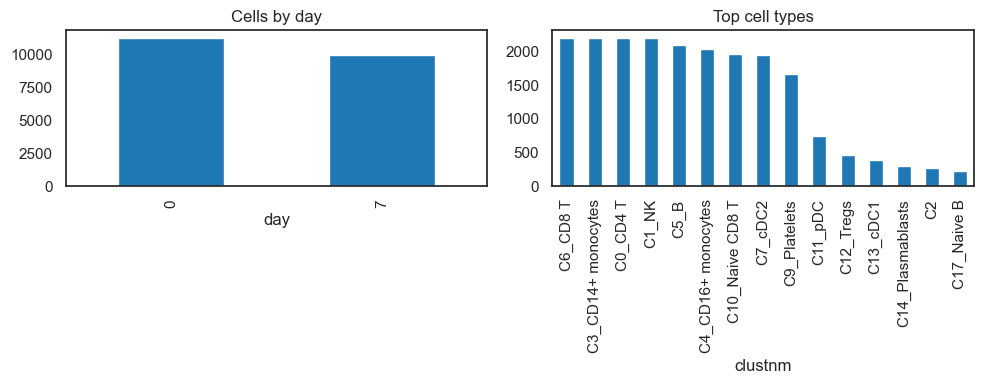

In [4]:
print("Days:", adata.obs["day"].unique())
print("Participants:", adata.obs["pt_id"].nunique())
print("Cell types:", adata.obs["clustnm"].nunique())
# Participants per day (before pairing restriction for analysis)
pt_per_day = adata.obs.groupby("day")["pt_id"].nunique().sort_index()
print("Participants per day:")
print(pt_per_day)
# Cell counts
eday_counts = adata.obs["day"].value_counts().sort_index()
ct_counts = adata.obs["clustnm"].value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eday_counts.plot(kind="bar", ax=axes[0], title="Cells by day")
ct_counts.plot(kind="bar", ax=axes[1], title="Top cell types")
plt.tight_layout(); plt.show()


## 3. Trial Design and Timepoint Strategy


In [5]:
# Ensure log1p CPM
if "log1p_cpm" not in adata.layers:
    adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")
# Standardize metadata
adata.obs["visit"] = adata.obs["day"].astype(str)
adata.obs["participant_id"] = adata.obs["pt_id"].astype(str)
adata.obs["arm"] = "Vaccinated"
adata.obs["cell_type"] = adata.obs["clustnm"].astype(str)
visit_col = "visit"
visits = [v for v in ["0", "7"] if v in adata.obs[visit_col].unique()]
# Participant-level pairing
participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_day0"] = participant_summary[visit_col].apply(lambda x: "0" in x)
participant_summary["has_day7"] = participant_summary[visit_col].apply(lambda x: "7" in x)
participant_summary["is_paired"] = participant_summary["has_day0"] & participant_summary["has_day7"]
paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])
n_paired = len(paired_ids)
print(f"Paired participants (0 vs 7): {n_paired}")
# Analysis subset: paired participants only
adata_analysis = adata[adata.obs["participant_id"].isin(paired_ids)].copy()
print(f"Analysis subset cells: {adata_analysis.n_obs}")
# Covariates (if available)
candidate_covariates = ["age", "sex", "batch", "site"]
covariates = [c for c in candidate_covariates if c in adata.obs.columns]
print("Covariates available (not modeled here):", covariates)
# Design object (single arm); arm labels are placeholders for API consistency
# We rely on paired within-participant tests, not treated vs control inference.
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col="arm",
    arm_treated="Vaccinated",
    arm_control="Vaccinated",
    celltype_col="cell_type",
)


Paired participants (0 vs 7): 6


Analysis subset cells: 21331
Covariates available (not modeled here): []


### 3.1 Exploratory plots of cell types per visit


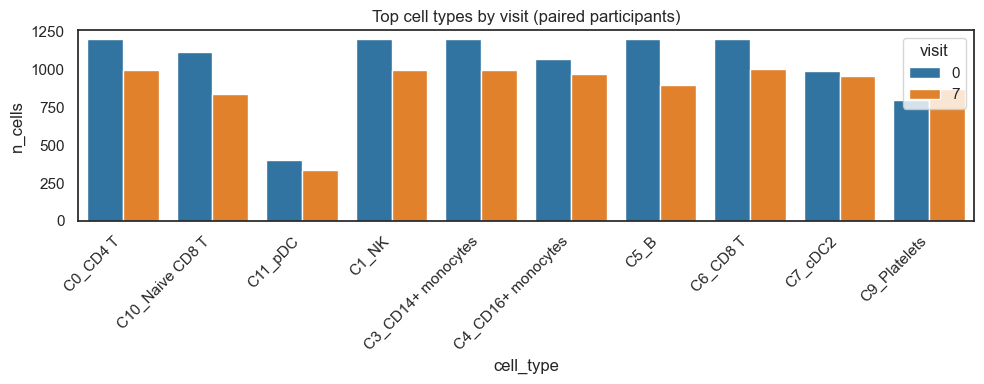

In [6]:
ct_visit = (
    adata_analysis.obs
    .groupby([design.celltype_col, design.visit_col], observed=True)
    .size()
    .reset_index(name="n_cells")
)
top_ct = adata_analysis.obs[design.celltype_col].value_counts().head(10).index
ct_visit_top = ct_visit[ct_visit[design.celltype_col].isin(top_ct)].copy()
plt.figure(figsize=(10, 4))
sns.barplot(data=ct_visit_top, x=design.celltype_col, y="n_cells", hue=design.visit_col)
plt.title("Top cell types by visit (paired participants)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


## 4. UMAPs of All Cell Types

Here, we explore global structure across all cell types to understand broad immune landscape changes.


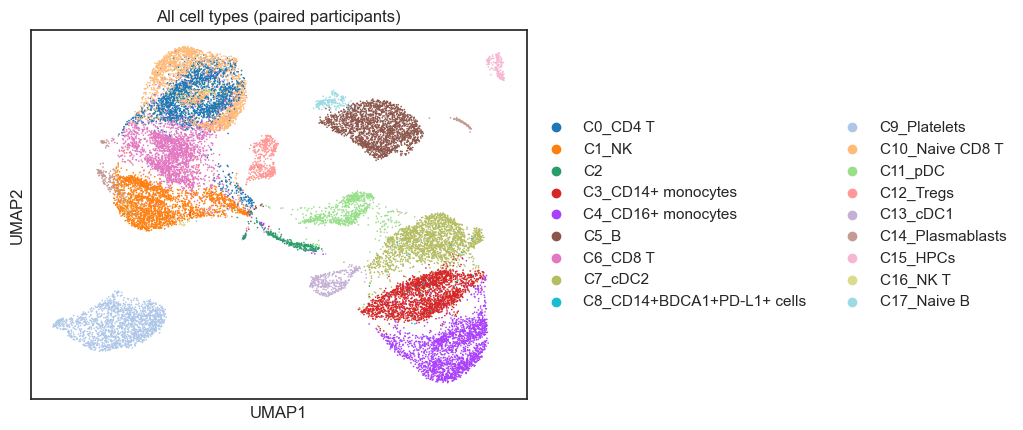

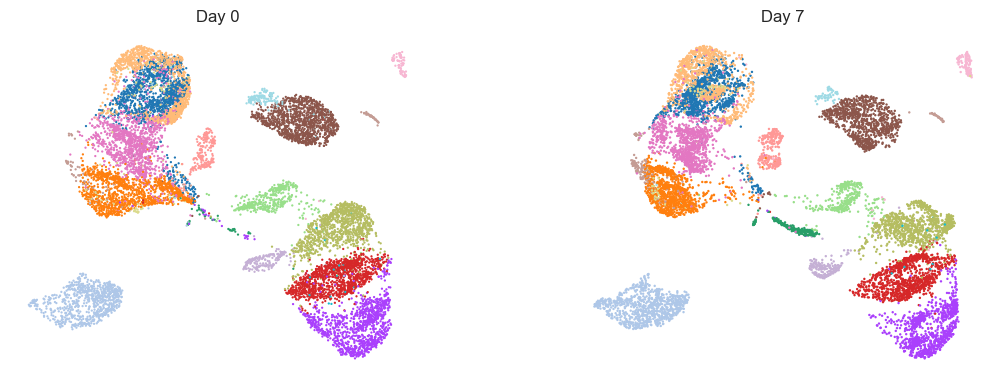

In [7]:
# Compute UMAP on log1p CPM if missing
adata_umap = adata_analysis.copy()
adata_umap.X = adata_umap.layers["log1p_cpm"].copy()
if "X_umap" not in adata_umap.obsm:
    sc.pp.pca(adata_umap)
    sc.pp.neighbors(adata_umap)
    sc.tl.umap(adata_umap)
sc.pl.umap(
    adata_umap,
    color=design.celltype_col,
    legend_loc="right margin",
    title="All cell types (paired participants)",
)
# Stratified UMAPs by visit
fig, axes = plt.subplots(1, len(visits), figsize=(12, 4))
if len(visits) == 1:
    axes = [axes]
for i, vis in enumerate(visits):
    sub = adata_umap[adata_umap.obs[design.visit_col] == vis].copy()
    ax = axes[i]
    if sub.n_obs > 0:
        sc.pl.umap(sub, color=design.celltype_col, ax=ax, show=False, legend_loc=None, frameon=False)
        ax.set_title(f"Day {vis}")
        ax.set_aspect('equal')
    else:
        ax.set_axis_off()
plt.tight_layout(); plt.show()


## 5. Module Scoring and Gene Panel

Here, we define biologically motivated signatures and a focused gene panel for downstream within‑arm testing.


In [8]:
available = set(adata_analysis.var_names)
# Define immunologically relevant gene sets for vaccine response
# Expanded to include T cell responses which are critical for vaccine immunity
raw_gene_sets = {
    "B_Cell_Response": ["CD79A", "CD79B", "MS4A1", "MZB1", "XBP1", "JCHAIN", "IGHG1", "IGHA1"],
    "IFN_Signature": ["ISG15", "IFI6", "IFIT1", "IFIT3", "MX1", "STAT1", "OAS1", "IRF7"],
    "Inflammatory": ["S100A8", "S100A9", "LYZ", "VCAN", "IL1B", "CXCL8", "CCL2"],
    "T_Cell_Activation": ["CD69", "CD38", "HLA-DRA", "ICOS", "IL2RA", "TNFRSF9"],
    "Cytotoxic": ["GZMB", "GZMA", "PRF1", "GNLY", "NKG7", "IFNG"],
    "Memory_T": ["IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27"],
}
print("Gene set coverage:")
filtered = {}
for name, genes in raw_gene_sets.items():
    present = [g for g in genes if g in available]
    pct = len(present) / len(genes) * 100 if genes else 0
    status = "OK" if len(present) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"  {name}: {len(present)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(present) >= MIN_GENES_FOR_SCORE:
        filtered[name] = present
if filtered:
    adata_analysis = st.score_gene_sets(
        adata_analysis, filtered, layer="log1p_cpm", method="zmean", prefix="ms_"
    )
    print(f"\nScored {len(filtered)} gene sets using zmean.")
else:
    print(f"\nNo gene sets matched (min_genes={MIN_GENES_FOR_SCORE}); skipping module scoring.")
features = [c for c in adata_analysis.obs.columns if c.startswith("ms_")]
print("Module score features:", features)
# Panel genes for individual gene analysis (expanded)
panel_genes_all = [
    # B cell
    "CD79A", "CD79B", "MS4A1", "MZB1", "XBP1",
    # IFN
    "ISG15", "IFI6", "IFIT1", "MX1",
    # Inflammatory
    "S100A8", "S100A9", "LYZ", "VCAN",
    # T cell activation
    "CD69", "CD38", "IL2RA",
    # Cytotoxic
    "GZMB", "PRF1", "NKG7",
]
panel_genes = [g for g in panel_genes_all if g in available]
missing_panel = [g for g in panel_genes_all if g not in available]
print("\nPanel genes (available):", panel_genes)
if missing_panel:
    print("Panel genes missing:", missing_panel)


Gene set coverage:
  B_Cell_Response: 8/8 genes (100%) [OK]
  IFN_Signature: 8/8 genes (100%) [OK]
  Inflammatory: 7/7 genes (100%) [OK]
  T_Cell_Activation: 6/6 genes (100%) [OK]
  Cytotoxic: 6/6 genes (100%) [OK]
  Memory_T: 6/6 genes (100%) [OK]

Scored 6 gene sets using zmean.
Module score features: ['ms_B_Cell_Response', 'ms_IFN_Signature', 'ms_Inflammatory', 'ms_T_Cell_Activation', 'ms_Cytotoxic', 'ms_Memory_T']

Panel genes (available): ['CD79A', 'CD79B', 'MS4A1', 'MZB1', 'XBP1', 'ISG15', 'IFI6', 'IFIT1', 'MX1', 'S100A8', 'S100A9', 'LYZ', 'VCAN', 'CD69', 'CD38', 'IL2RA', 'GZMB', 'PRF1', 'NKG7']


In [9]:
# ============================================================================
# PAIRING VERIFICATION (package helper)
# ============================================================================
print("=" * 60)
print("PAIRING VERIFICATION (based on valid signature scores)")
print("=" * 60)
paired_info = verify_paired_participants(
    adata_analysis.obs,
    visit_col=visit_col,
    visits=visits,
    features=features,
    participant_col="participant_id",
)
VALID_PAIRED_IDS = paired_info["paired_ids"]
N_VALID_PAIRED = paired_info["n_paired"]
print("")
print(f"Participants with valid Day0+Day7 scores for ALL features: {N_VALID_PAIRED}")
print(f"Total participants: {paired_info['n_total']}")
if paired_info["dropped_ids"]:
    print(f"Dropped (missing visit or NaN features): {len(paired_info['dropped_ids'])}")
else:
    print("All paired participants have valid scores ✓")
print("")
print(f"Using {N_VALID_PAIRED} validated paired participants for analyses.")


PAIRING VERIFICATION (based on valid signature scores)

Participants with valid Day0+Day7 scores for ALL features: 6
Total participants: 6
All paired participants have valid scores ✓

Using 6 validated paired participants for analyses.


## 6. Within-Arm Comparisons (Participant-Level)

Here, we run paired within‑participant analyses to determine which module scores change from Day 0 to Day 7.


WITHIN-ARM COMPARISONS: MODULE SCORES (Day 0 vs Day 7)


,feature,beta_time,p_time,FDR_time,n_units
0,ms_B_Cell_Response,0.1108,0.9012,0.9060,6
1,ms_IFN_Signature,0.6007,0.3358,0.6717,6
2,ms_Inflammatory,-0.1222,0.9060,0.9060,6
3,ms_T_Cell_Activation,0.7555,0.2599,0.6717,6
4,ms_Cytotoxic,0.9041,0.3215,0.6717,6
5,ms_Memory_T,-0.4674,0.6293,0.9060,6



No module scores reached FDR < 0.25.

Boxplots show participant-level distributions by day; points indicate individual participants.


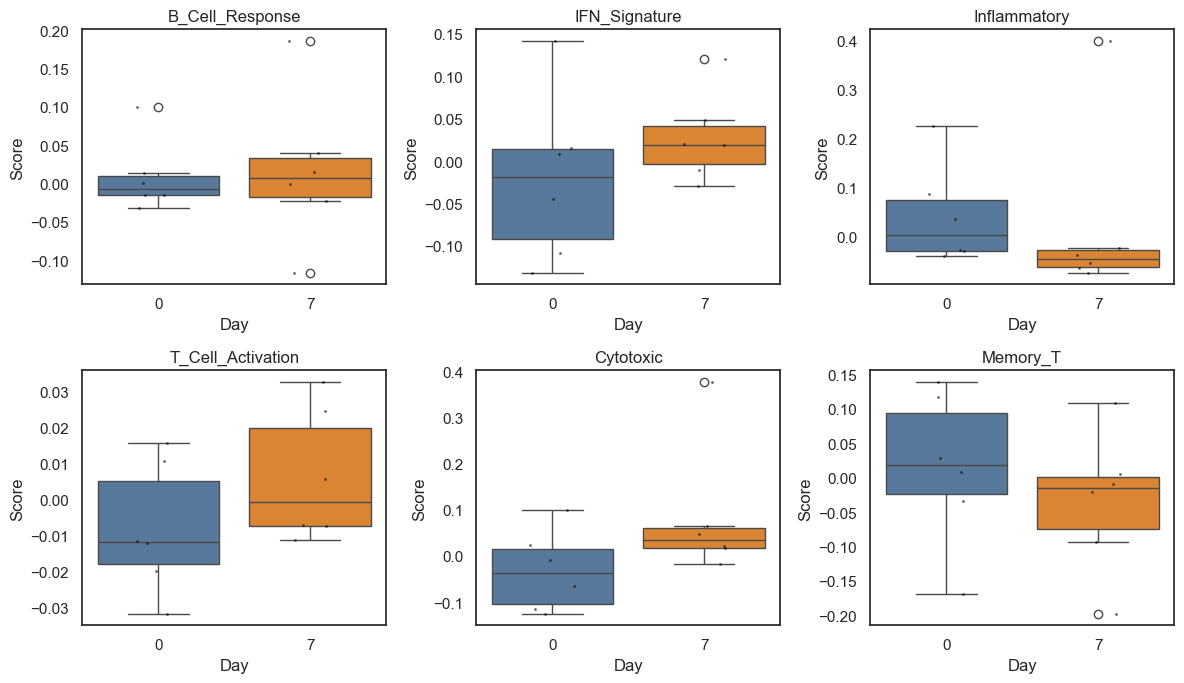

In [10]:
print("=" * 60)
print("WITHIN-ARM COMPARISONS: MODULE SCORES (Day 0 vs Day 7)")
print("=" * 60)
res_within = pd.DataFrame()
if features and len(visits) == 2:
    ad_sub = adata_analysis[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)].copy()
    res_within = st.within_arm_comparison(
        ad_sub,
        arm="Vaccinated",
        features=features,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
    )
    if res_within is not None and not res_within.empty:
        if "FDR_time" not in res_within.columns and "p_time" in res_within.columns:
            mask = res_within["p_time"].notna()
            res_within["FDR_time"] = np.nan
            if mask.sum() > 0:
                res_within.loc[mask, "FDR_time"] = multipletests(
                    res_within.loc[mask, "p_time"], method="fdr_bh"
                )[1]
        display_cols = ["feature", "beta_time", "p_time", "FDR_time", "n_units"]
        display_cols = [c for c in display_cols if c in res_within.columns]
        display(res_within[display_cols].round(4))
        sig = res_within[(res_within["FDR_time"].notna()) & (res_within["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Module score changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "increased" if row["beta_time"] > 0 else "decreased"
                print(f"  {row['feature']}: {direction} (β={row['beta_time']:.3f}, FDR={row['FDR_time']:.3f})")
        else:
            print("")
            print(f"No module scores reached FDR < {FDR_ALPHA}.")
    else:
        print("No within-arm results for module scores.")
else:
    print("Insufficient features or visits for within-arm comparisons.")
print("")
print("Boxplots show participant-level distributions by day; points indicate individual participants.")
# Plot participant-level module scores by day
if features and len(visits) == 2:
    df_plot = (
        adata_analysis.obs
        .groupby(["participant_id", "visit"], observed=True)[features]
        .mean()
        .reset_index()
    )
    n_feats = len(features)
    n_cols = min(3, n_feats)
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = np.array(axes).reshape(-1)
    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(
            data=df_plot,
            x="visit",
            y=feat,
            hue="visit",
            ax=ax,
            order=visits,
            palette={"0": "#4C78A8", "7": "#F58518"},
            dodge=False,
            linewidth=1,
        )
        sns.stripplot(
            data=df_plot,
            x="visit",
            y=feat,
            ax=ax,
            order=visits,
            color="black",
            size=2,
            alpha=0.6,
            jitter=0.15,
        )
        ax.set_title(feat.replace("ms_", ""))
        ax.set_xlabel("Day")
        ax.set_ylabel("Score")
        if ax.legend_:
            ax.legend_.remove()
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


### Module-Score Pseudobulk by Cell Type (Within-Arm)

Here, we aggregate module scores to participant×visit×cell_type (pseudobulk) and test paired Day 0→Day 7 changes within the vaccinated arm for each cell type.


,pool,module,mean_delta,p_time,n_units,FDR_time
21,C12_Tregs,ms_Inflammatory,-0.170378,0.0625,5,0.118056
47,C16_NK T,ms_T_Cell_Activation,0.144895,0.0625,5,0.354167
55,C1_NK,ms_Cytotoxic,0.272274,0.0625,5,0.354167
56,C1_NK,ms_IFN_Signature,0.073823,0.0625,5,0.106250
57,C1_NK,ms_Inflammatory,-0.156709,0.0625,5,0.118056
33,C14_Plasmablasts,ms_Inflammatory,-0.111641,0.0625,5,0.118056
59,C1_NK,ms_T_Cell_Activation,0.052057,0.0625,5,0.354167
31,C14_Plasmablasts,ms_Cytotoxic,0.591136,0.0625,5,0.354167
68,C3_CD14+ monocytes,ms_IFN_Signature,0.103884,0.0625,5,0.106250
74,C4_CD16+ monocytes,ms_IFN_Signature,0.147047,0.0625,5,0.106250


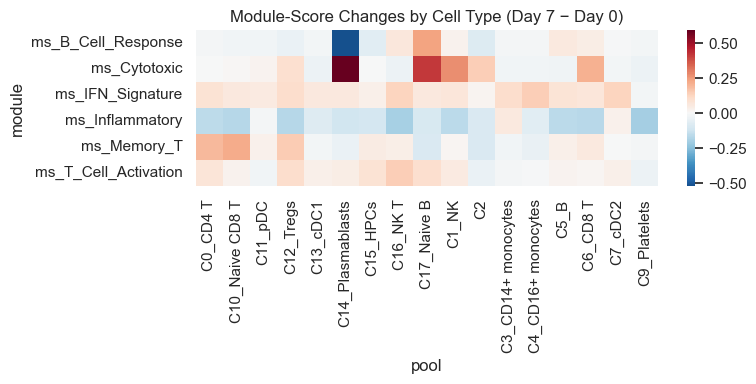

In [11]:
if features and len(visits) == 2:
    pb_mod = st.module_score_pseudobulk(
        adata_analysis,
        module_cols=features,
        design=design,
        visits=tuple(visits),
        pool_col="cell_type",
        min_cells_per_group=5,
    )
    res_mod_ct = st.module_score_within_arm_by_pool(
        pb_mod,
        design=design,
        visits=tuple(visits),
        min_paired=3,
        fdr_within="module",
    )
    if not res_mod_ct.empty:
        display(res_mod_ct.sort_values("p_time").head(20))
        pivot = res_mod_ct.pivot(index="module", columns="pool", values="mean_delta")
        plt.figure(figsize=(8, max(4, 0.35*len(pivot))))
        sns.heatmap(pivot, cmap="RdBu_r", center=0)
        plt.title("Module-Score Changes by Cell Type (Day 7 − Day 0)")
        plt.tight_layout()
        plt.show()
    else:
        print("No valid pseudobulk module-score results for cell types.")
else:
    print("Skipping pseudobulk module-score analysis: insufficient features or visits.")


## 7. Gene Expression Within-Arm (Panel Genes)

Here, we test targeted panel genes for within‑arm changes using participant‑level aggregation.


WITHIN-ARM COMPARISONS: PANEL GENES (Day 0 vs Day 7)


,feature,beta_time,p_time,FDR_time,n_units
0,CD79A,-0.2122,0.8221,0.9581,6
1,CD79B,0.2711,0.8031,0.9581,6
2,MS4A1,-0.6702,0.3075,0.9581,6
3,MZB1,0.2472,0.7017,0.9581,6
4,XBP1,0.0470,0.9465,0.9581,6
5,ISG15,0.7015,0.4493,0.9581,6
6,IFI6,0.7143,0.0000,0.0000,6
7,IFIT1,0.3211,0.6061,0.9581,6
8,MX1,0.3230,0.4390,0.9581,6
9,S100A8,0.0531,0.9581,0.9581,6



Panel genes with significant changes (FDR < 0.25):
  IFI6: increased (β=0.714, FDR=0.000)

Boxplots show participant-level log1p CPM by day; points indicate individual participants.


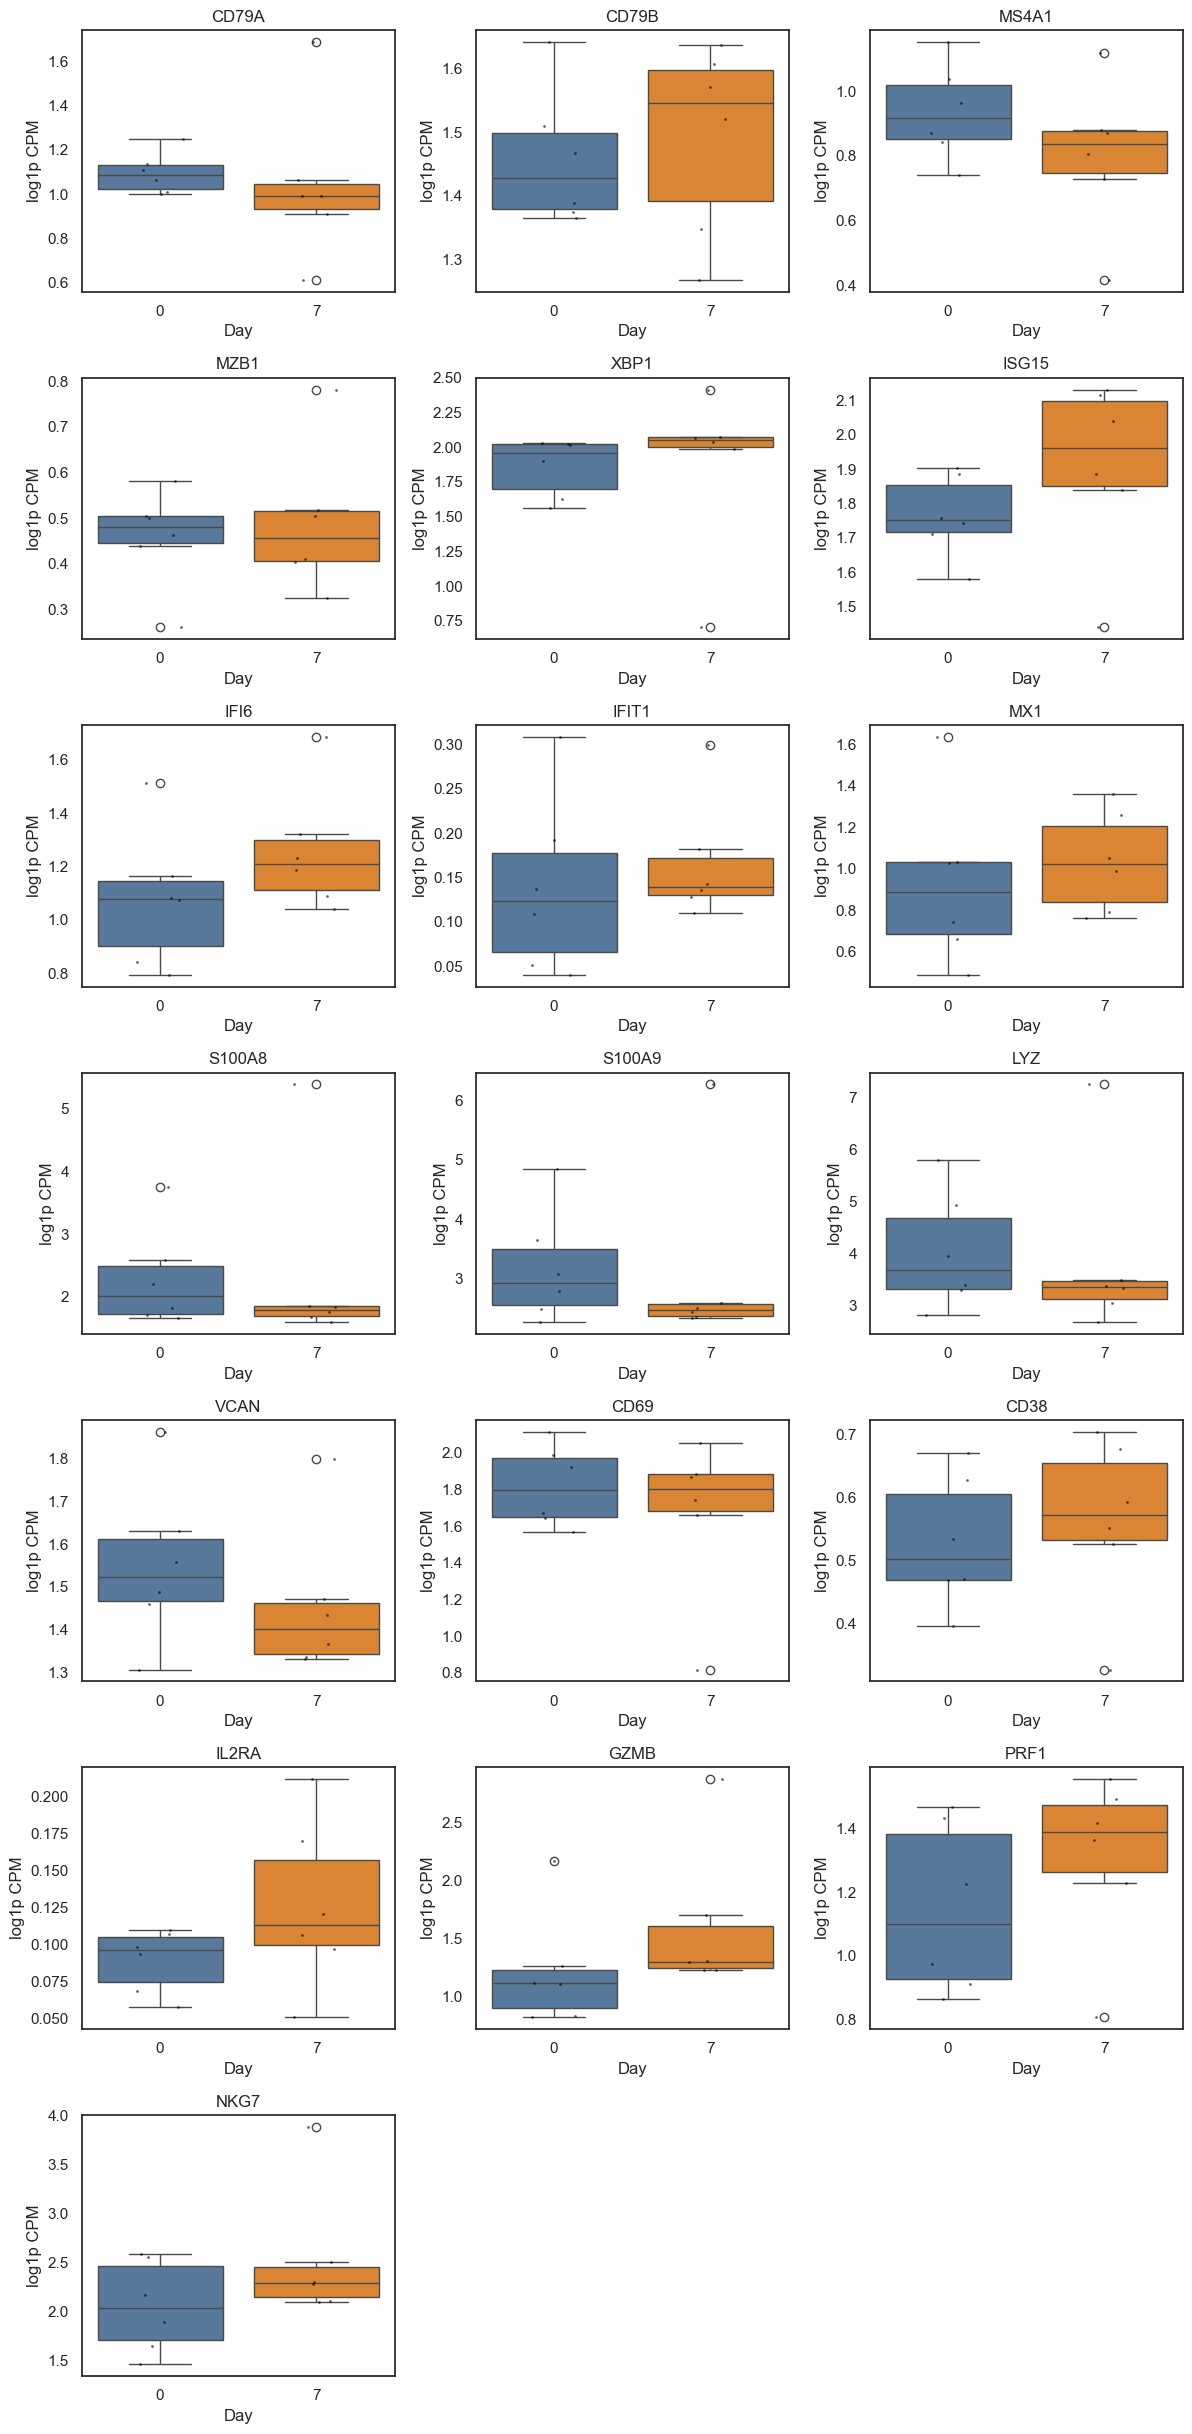

In [12]:
print("=" * 60)
print("WITHIN-ARM COMPARISONS: PANEL GENES (Day 0 vs Day 7)")
print("=" * 60)
res_genes = pd.DataFrame()
if panel_genes and len(visits) == 2:
    ad_sub = adata_analysis[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)].copy()
    res_genes = st.within_arm_comparison(
        ad_sub,
        arm="Vaccinated",
        features=panel_genes,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
        layer="log1p_cpm",
    )
    if res_genes is not None and not res_genes.empty:
        if "FDR_time" not in res_genes.columns and "p_time" in res_genes.columns:
            mask = res_genes["p_time"].notna()
            res_genes["FDR_time"] = np.nan
            if mask.sum() > 0:
                res_genes.loc[mask, "FDR_time"] = multipletests(
                    res_genes.loc[mask, "p_time"], method="fdr_bh"
                )[1]
        display_cols = ["feature", "beta_time", "p_time", "FDR_time", "n_units"]
        display_cols = [c for c in display_cols if c in res_genes.columns]
        display(res_genes[display_cols].round(4))
        sig = res_genes[(res_genes["FDR_time"].notna()) & (res_genes["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Panel genes with significant changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "increased" if row["beta_time"] > 0 else "decreased"
                print(f"  {row['feature']}: {direction} (β={row['beta_time']:.3f}, FDR={row['FDR_time']:.3f})")
        else:
            print("")
            print(f"No panel genes reached FDR < {FDR_ALPHA}.")
    else:
        print("No within-arm results for panel genes.")
else:
    print("No panel genes available or missing visits.")
print("")
print("Boxplots show participant-level log1p CPM by day; points indicate individual participants.")
# Plot participant-level panel genes by day (log1p CPM)
if panel_genes and len(visits) == 2:
    df_expr = adata_analysis.obs[["participant_id", "visit"]].copy()
    for g in panel_genes:
        df_expr[g] = st.extract_gene_vector(adata_analysis, g, layer="log1p_cpm")
    df_plot = (
        df_expr
        .groupby(["participant_id", "visit"], observed=True)[panel_genes]
        .mean()
        .reset_index()
    )
    n_feats = len(panel_genes)
    n_cols = min(3, n_feats)
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = np.array(axes).reshape(-1)
    for i, feat in enumerate(panel_genes):
        ax = axes[i]
        sns.boxplot(
            data=df_plot,
            x="visit",
            y=feat,
            hue="visit",
            ax=ax,
            order=visits,
            palette={"0": "#4C78A8", "7": "#F58518"},
            dodge=False,
            linewidth=1,
        )
        sns.stripplot(
            data=df_plot,
            x="visit",
            y=feat,
            ax=ax,
            order=visits,
            color="black",
            size=2,
            alpha=0.6,
            jitter=0.15,
        )
        ax.set_title(feat)
        ax.set_xlabel("Day")
        ax.set_ylabel("log1p CPM")
        if ax.legend_:
            ax.legend_.remove()
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


## 8. Pseudobulk Within-Arm (Panel Genes)

Here, we aggregate counts to pseudobulk profiles and quantify gene‑level shifts by cell type.


Pseudobulk paired deltas with Wilcoxon signed-rank test (panel genes × cell type):


,celltype,feature,n_units,mean_delta,median_delta,p_time,FDR_time
217,C3_CD14+ monocytes,MX1,6,0.376383,0.397559,0.03125,0.363153
222,C3_CD14+ monocytes,CD69,6,-1.000836,-0.699824,0.03125,0.363153
284,C6_CD8 T,NKG7,6,0.406716,0.355028,0.03125,0.363153
278,C6_CD8 T,VCAN,6,-0.986688,-0.894316,0.03125,0.363153
283,C6_CD8 T,PRF1,6,0.662143,0.633262,0.03125,0.363153
188,C1_NK,PRF1,5,0.300962,0.254804,0.06250,0.363153
225,C3_CD14+ monocytes,GZMB,6,-0.894293,-1.008885,0.06250,0.363153
189,C1_NK,NKG7,5,0.334008,0.208272,0.06250,0.363153
256,C5_B,S100A8,5,-1.368936,-1.233742,0.06250,0.363153
257,C5_B,S100A9,5,-1.506106,-1.401379,0.06250,0.363153


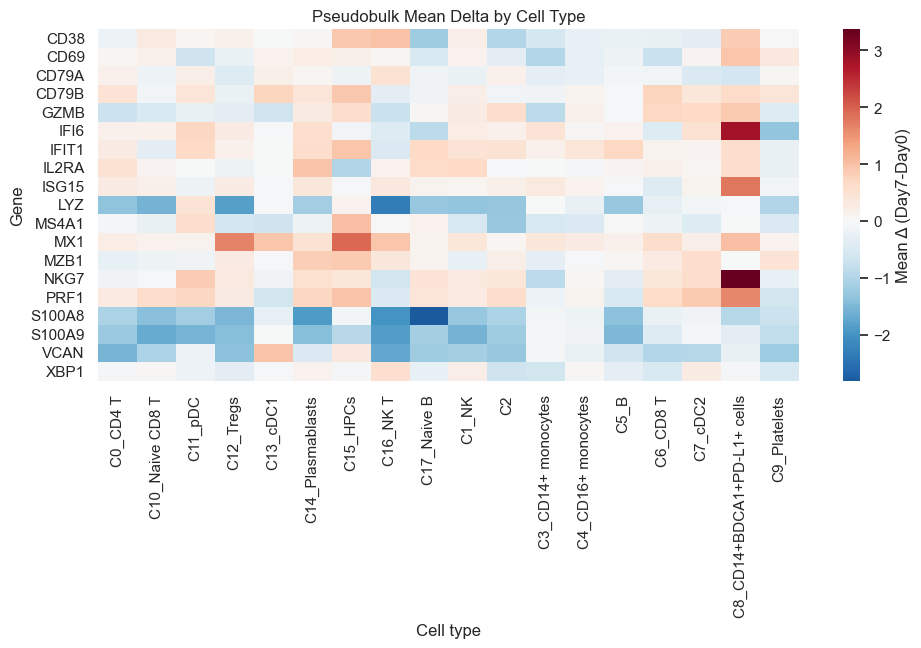

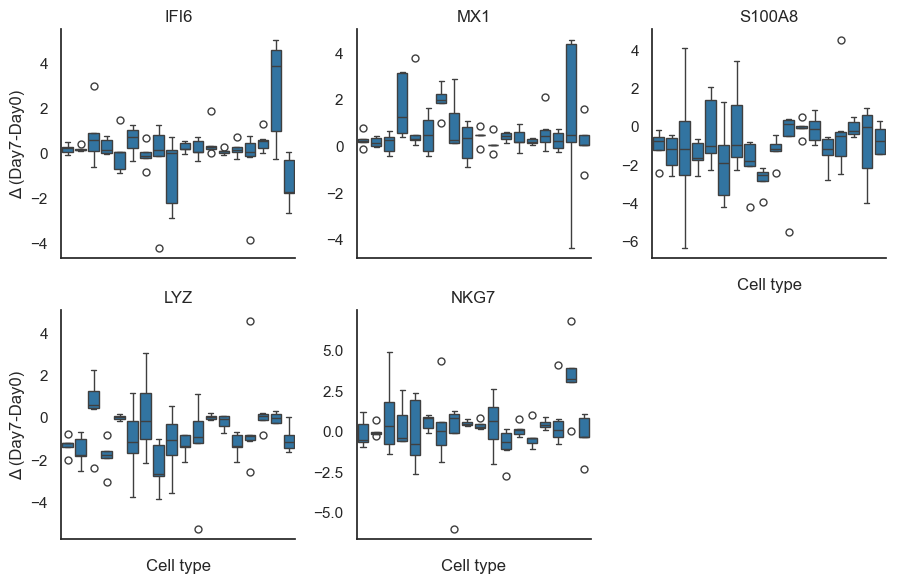

In [13]:
from scipy.stats import wilcoxon
if panel_genes and n_paired >= MIN_PAIRED and len(visits) == 2:
    # Use package helper for pseudobulk within-arm analysis
    pb, pb_deltas = st.pseudobulk_within_arm(
        adata_analysis,
        genes=panel_genes,
        participant_col="participant_id",
        visit_col=design.visit_col,
        visits=visits,
        celltype_col=design.celltype_col,
        counts_layer="counts",
        min_paired=MIN_PAIRED,
    )
    if not pb.empty:
        print("Pseudobulk paired deltas with Wilcoxon signed-rank test (panel genes × cell type):")
        display(pb.sort_values(["p_time"]).head(30))
        sig = pb[(pb["FDR_time"].notna()) & (pb["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Significant pseudobulk changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "↑" if row["mean_delta"] > 0 else "↓"
                print(f"  {row['celltype']} - {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={row['FDR_time']:.3f})")
    else:
        print("No pseudobulk results generated.")
    # Pseudobulk heatmap (mean delta by cell type × gene)
    if not pb.empty:
        sns.set_style("white")
        pivot = pb.pivot(index="feature", columns="celltype", values="mean_delta")
        plt.figure(figsize=(10, max(4, 0.35*len(pivot))))
        ax = plt.gca()
        sns.heatmap(
            pivot,
            cmap="RdBu_r",
            center=0,
            cbar_kws={"label": "Mean Δ (Day7-Day0)"},
            linewidths=0,
            linecolor="none",
        )
        ax.set_axisbelow(False)
        plt.title("Pseudobulk Mean Delta by Cell Type")
        plt.xlabel("Cell type")
        plt.ylabel("Gene")
        plt.tight_layout()
        plt.show()
    # Distribution plots for top genes (by absolute mean delta)
    if not pb.empty and not pb_deltas.empty:
        top_genes = (
            pb.assign(abs_delta=pb["mean_delta"].abs())
            .sort_values("abs_delta", ascending=False)
            .head(6)["feature"].unique()
        )
        plot_df = pb_deltas[pb_deltas["feature"].isin(top_genes)].copy()
        if not plot_df.empty:
            g = sns.catplot(
                data=plot_df,
                x="celltype",
                y="delta",
                col="feature",
                kind="box",
                col_wrap=3,
                sharey=False,
                height=3,
            )
            g.set_titles("{col_name}")
            g.set_xticklabels(rotation=45, ha="right")
            g.set_axis_labels("Cell type", "Δ (Day7-Day0)")
            plt.tight_layout()
            plt.show()
else:
    print("Insufficient paired participants for pseudobulk.")


## 9. Trial Interaction Plot (Single Arm)

Here, we visualize paired trajectories to interpret direction and magnitude of change.


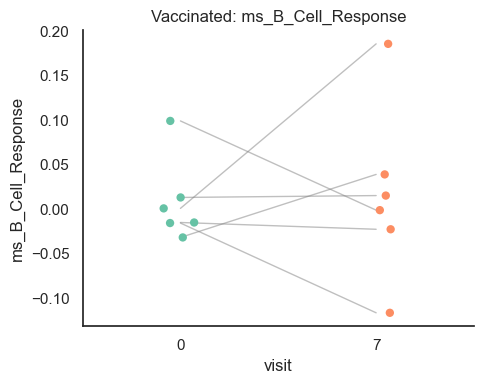

In [14]:
if features and len(visits) == 2:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_within_arm_comparison(
        adata_analysis,
        arm="Vaccinated",
        feature=features[0],
        design=design,
        visits=tuple(visits),
        plot_type="paired",
        ax=ax,
    )
    plt.tight_layout(); plt.show()


## 10. Trial UMAP Panel for a Module Score

Here, we overlay a module score on the UMAP to localize signal to specific cell populations.


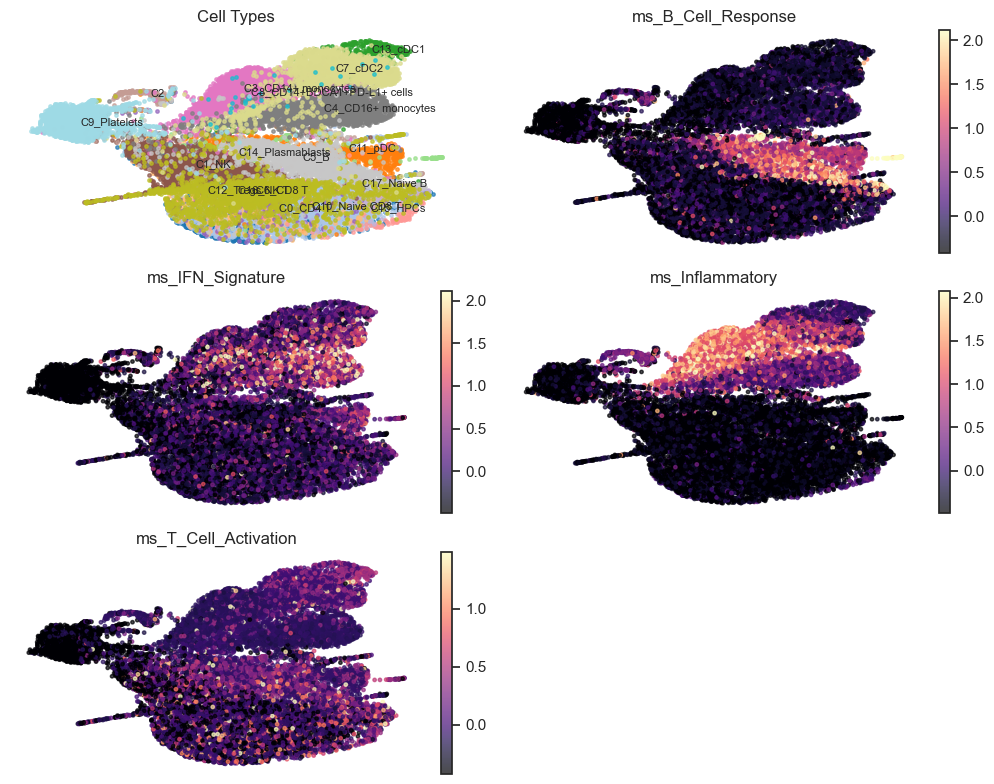

In [15]:
if features:
    modules = features[:4]
    if "X_umap" not in adata_analysis.obsm:
        sc.pp.pca(adata_analysis)
        sc.pp.neighbors(adata_analysis)
        sc.tl.umap(adata_analysis)
    fig = st.plot_module_umap_panel(
        adata_analysis,
        module_cols=modules,
        celltype_col="cell_type",
        umap_key="X_umap",
        n_cols=2,
        figsize=(10, 8),
        point_size=6,
        alpha=0.7,
    )
    plt.show()
else:
    print("No module scores available for UMAP panel.")


## 11. Dotplot of Panel Genes

Here, we summarize gene expression patterns across cell types in a compact dotplot.


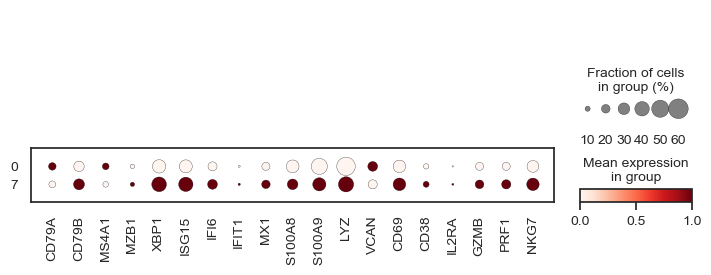

In [16]:
if panel_genes:
    sc.pl.dotplot(
        adata_analysis,
        panel_genes,
        groupby=design.visit_col,
        standard_scale="var",
        use_raw=False,
    )


## 12. Advanced Statistical Analyses

This section demonstrates the new statistical modules for within-arm longitudinal studies:
- **Effect sizes**: Cohen's d for paired within-arm changes
- **Power analysis**: Current power and sample size planning
- **Effective sample size**: Accounting for cell-level clustering


### 12.1 Effect Sizes for Within-Arm Changes

For within-arm studies without a control group, effect sizes quantify the magnitude of change from baseline.


EFFECT SIZE ANALYSIS (Within-Arm)

Effect sizes for Day 0 → Day 7 changes:
  d_paired: standardized within-subject change
  Hedge's g: bias-corrected between-group effect size



,feature,mean_delta,d_paired,cohens_d,hedges_g,ci_lower,ci_upper,n_paired
0,ms_B_Cell_Response,0.008,0.075,0.106,0.098,-1.146,1.232,6
1,ms_IFN_Signature,0.048,0.583,0.603,0.557,-0.418,2.035,6
2,ms_Inflammatory,-0.017,-0.071,-0.117,-0.108,-2.003,0.776,6
3,ms_T_Cell_Activation,0.014,0.682,0.784,0.723,-0.231,2.070,6
4,ms_Cytotoxic,0.117,0.600,0.978,0.902,0.161,2.181,6
5,ms_Memory_T,-0.049,-0.292,-0.460,-0.424,-1.853,0.586,6


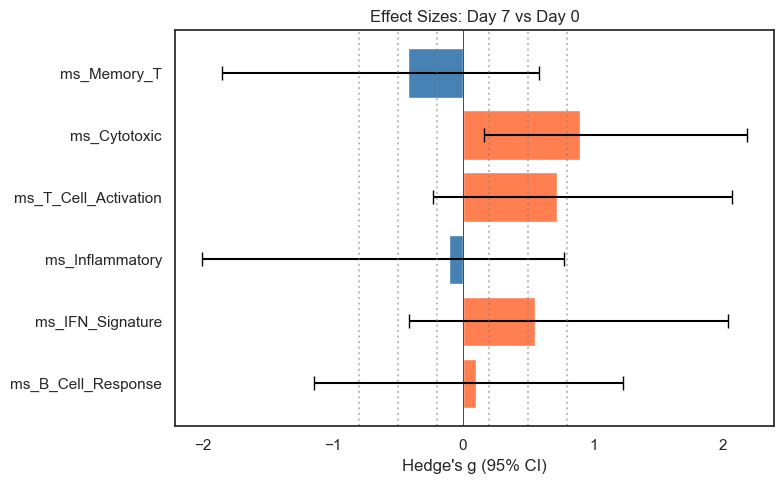

In [17]:
print("=" * 60)
print("EFFECT SIZE ANALYSIS (Within-Arm)")
print("=" * 60)
if features and len(visits) == 2:
    # Aggregate to participant-visit level
    df_agg = (
        adata_analysis.obs[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)]
        .groupby(["participant_id", "visit"], observed=True)[features]
        .mean()
        .reset_index()
    )
    
    effect_results = []
    for feat in features:
        # Pivot to wide format
        wide = df_agg.pivot(index="participant_id", columns="visit", values=feat)
        
        if visits[0] not in wide.columns or visits[1] not in wide.columns:
            continue
        
        wide = wide.dropna()
        pre_vals = wide[visits[0]].values
        post_vals = wide[visits[1]].values
        
        if len(pre_vals) >= 3:
            # Cohen's d for paired samples (standardized mean difference)
            delta = post_vals - pre_vals
            d_paired = delta.mean() / delta.std(ddof=1) if delta.std(ddof=1) > 0 else np.nan
            
            # Also compute Cohen's d comparing post vs pre distributions
            d_groups = st.cohens_d(post_vals, pre_vals)
            g_groups = st.hedges_g(post_vals, pre_vals)
            
            # Bootstrap CI for effect size (returns: effect_size, ci_lower, ci_upper)
            try:
                _, ci_low, ci_high = st.bootstrap_effect_size_ci(
                    post_vals, pre_vals,
                    n_boot=999,
                    alpha=0.05,
                    seed=SEED
                )
            except Exception:
                ci_low, ci_high = np.nan, np.nan
            
            effect_results.append({
                "feature": feat,
                "mean_delta": delta.mean(),
                "d_paired": d_paired,
                "cohens_d": d_groups,
                "hedges_g": g_groups,
                "ci_lower": ci_low,
                "ci_upper": ci_high,
                "n_paired": len(pre_vals),
            })
    
    if effect_results:
        df_effect = pd.DataFrame(effect_results)
        
        print("\nEffect sizes for Day 0 → Day 7 changes:")
        print("  d_paired: standardized within-subject change")
        print("  Hedge's g: bias-corrected between-group effect size")
        print("")
        display(df_effect.round(3))
        
        # Visualize
        fig, ax = plt.subplots(figsize=(8, 5))
        y_pos = np.arange(len(df_effect))
        
        ax.barh(y_pos, df_effect["hedges_g"], xerr=[
            df_effect["hedges_g"] - df_effect["ci_lower"],
            df_effect["ci_upper"] - df_effect["hedges_g"]
        ], capsize=5, color=["coral" if g > 0 else "steelblue" for g in df_effect["hedges_g"]])
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_effect["feature"])
        ax.set_xlabel("Hedge's g (95% CI)")
        ax.set_title("Effect Sizes: Day 7 vs Day 0")
        
        # Reference lines
        for thresh in [-0.8, -0.5, -0.2, 0.2, 0.5, 0.8]:
            ax.axvline(thresh, color="gray", linestyle=":", alpha=0.5)
        
        plt.tight_layout()
        plt.show()
else:
    print("Effect size analysis requires paired visits.")


### 12.2 Power Analysis

Power analysis for within-arm studies helps plan future studies and understand current study limitations.


POWER ANALYSIS (Within-Arm Paired Design)

Current paired sample size: 6 participants

Power with n=6 paired participants:
  Effect size d=0.5: 13.9% power
  Effect size d=0.8: 28.3% power
  Effect size d=1.0: 41.0% power
  Effect size d=1.5: 73.8% power
  Effect size d=2.0: 93.4% power

Sample size needed for 80% power (paired design):
  Effect size d=0.5: 63 participants
  Effect size d=0.8: 25 participants
  Effect size d=1.0: 16 participants
  Effect size d=1.5: 7 participants
  Effect size d=2.0: 4 participants


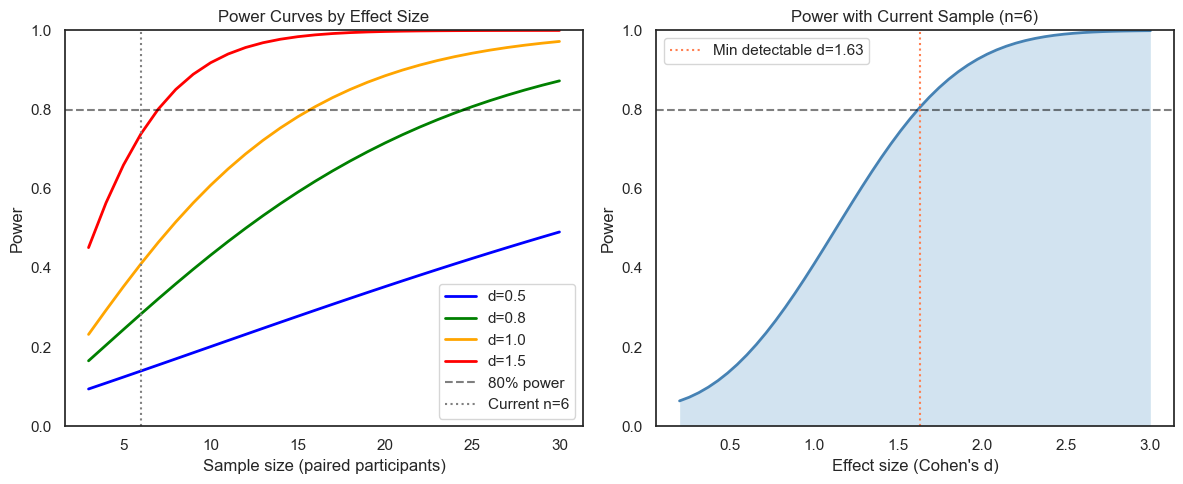


EFFECTIVE SAMPLE SIZE

Cells: 21,331
Average cells per participant: 3555

Design effect (cells within participant):
  ICC=0.01: Design effect=36.5, Effective n=2075309
  ICC=0.05: Design effect=178.7, Effective n=424352
  ICC=0.1: Design effect=356.4, Effective n=212771
  ICC=0.2: Design effect=711.8, Effective n=106535

Note: Participant-level aggregation accounts for clustering automatically.


In [18]:
print("=" * 60)
print("POWER ANALYSIS (Within-Arm Paired Design)")
print("=" * 60)
# Current sample size
n_paired = N_VALID_PAIRED
print(f"\nCurrent paired sample size: {n_paired} participants")
# Power for different effect sizes (using paired t-test approximation)
print(f"\nPower with n={n_paired} paired participants:")
for effect_size in [0.5, 0.8, 1.0, 1.5, 2.0]:
    # For paired design, use single-sample power calculation
    power = st.power_did(n_per_group=n_paired, effect_size=effect_size)
    print(f"  Effect size d={effect_size}: {power:.1%} power")
# Sample sizes needed for 80% power
print("\nSample size needed for 80% power (paired design):")
for effect_size in [0.5, 0.8, 1.0, 1.5, 2.0]:
    n_needed = st.sample_size_did(effect_size=effect_size, power=0.80)
    print(f"  Effect size d={effect_size}: {n_needed} participants")
# Power curve visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Power curve across sample sizes
n_range = np.arange(3, 31)
for effect_size, color in [(0.5, "blue"), (0.8, "green"), (1.0, "orange"), (1.5, "red")]:
    powers = [st.power_did(n_per_group=n, effect_size=effect_size) for n in n_range]
    axes[0].plot(n_range, powers, label=f"d={effect_size}", color=color, linewidth=2)
axes[0].axhline(0.8, color="black", linestyle="--", alpha=0.5, label="80% power")
axes[0].axvline(n_paired, color="gray", linestyle=":", label=f"Current n={n_paired}")
axes[0].set_xlabel("Sample size (paired participants)")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Curves by Effect Size")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0, 1)
# Power with current sample across effect sizes
effect_range = np.linspace(0.2, 3.0, 50)
power_current = [st.power_did(n_per_group=n_paired, effect_size=e) for e in effect_range]
axes[1].plot(effect_range, power_current, linewidth=2, color="steelblue")
axes[1].axhline(0.8, color="black", linestyle="--", alpha=0.5)
axes[1].fill_between(effect_range, 0, power_current, alpha=0.2)
axes[1].set_xlabel("Effect size (Cohen's d)")
axes[1].set_ylabel("Power")
axes[1].set_title(f"Power with Current Sample (n={n_paired})")
axes[1].set_ylim(0, 1)
# Mark minimum detectable effect
idx_80 = np.argmin(np.abs(np.array(power_current) - 0.8))
if idx_80 > 0:
    detectable = effect_range[idx_80]
    axes[1].axvline(detectable, color="coral", linestyle=":", 
                    label=f"Min detectable d={detectable:.2f}")
    axes[1].legend()
plt.tight_layout()
plt.show()
# Effective sample size
print("\n" + "=" * 60)
print("EFFECTIVE SAMPLE SIZE")
print("=" * 60)
cells_per_participant = adata_analysis.obs.groupby("participant_id").size()
avg_cells = cells_per_participant.mean()
total_cells = adata_analysis.n_obs
print(f"\nCells: {total_cells:,}")
print(f"Average cells per participant: {avg_cells:.0f}")
print("\nDesign effect (cells within participant):")
for icc in [0.01, 0.05, 0.10, 0.20]:
    de = st.design_effect(avg_cells, icc)
    eff_n = st.effective_sample_size(total_cells, avg_cells, icc)
    print(f"  ICC={icc}: Design effect={de:.1f}, Effective n={eff_n:.0f}")
print("\nNote: Participant-level aggregation accounts for clustering automatically.")


### Pseudobulk Export

Here we export participant-level pseudobulk expression for downstream analyses.


In [19]:
pb = st.pseudobulk_export(
    adata_analysis,
    genes=panel_genes[:5] if panel_genes else adata_analysis.var_names[:5],
    design=design,
    visits=tuple(visits),
    celltype_col=design.celltype_col,
)
print(pb)
display(pb.obs.head())


AnnData object with n_obs × n_vars = 202 × 5
    obs: 'participant_id', 'visit', 'arm', 'cell_type'


,participant_id,visit,arm,cell_type
0,2047,0,Vaccinated,C0_CD4 T
1,2047,0,Vaccinated,C10_Naive CD8 T
2,2047,0,Vaccinated,C11_pDC
3,2047,0,Vaccinated,C12_Tregs
4,2047,0,Vaccinated,C13_cDC1
